## Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

## Fractions

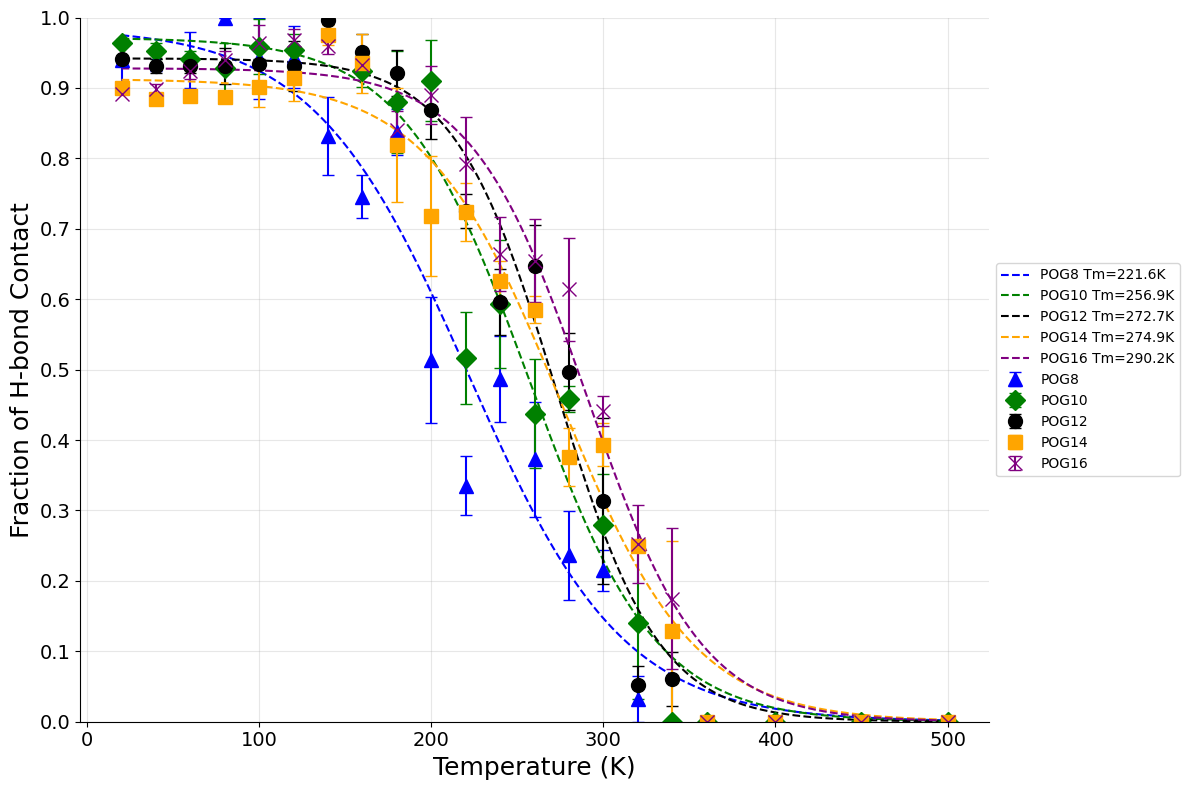

In [23]:
base_dir    = Path("./")
start_frame = 9703
threshold   = 350

systems = {
    #"POG6":  {"max_pairs": 16, "color": "red",   "marker": "s"},
    "POG8":  {"max_pairs": 22, "color": "blue",  "marker": "^"},
    "POG10": {"max_pairs": 28, "color": "green", "marker": "D"},
    "POG12": {"max_pairs": 34, "color": "black", "marker": "o"},
    "POG14":  {"max_pairs": 40, "color": "orange",  "marker": "s"},
    "POG16": {"max_pairs": 46, "color": "purple", "marker": "x"},
    "POG18": {"max_pairs": 52, "color": "pink", "marker": "v"},
    "POG20": {"max_pairs": 58, "color": "red", "marker": "P"}
}

fig, ax = plt.subplots(figsize=(12,8))

for sys_name, props in systems.items():
    csv_file = base_dir / sys_name / f"{sys_name}_replicas_fraction_summary.csv"
    df = pd.read_csv(csv_file)
    
    T_data = df["Temperature (K)"].values
    F_data = df["Fraction"].values
    E_data = df["StdErr"].values

    # pad zeros beyond threshold
    extra_T = np.arange(threshold+50, 501, 50)
    extra_F = np.zeros_like(extra_T, dtype=float)
    extra_e = np.zeros_like(extra_T, dtype=float)
    T_all = np.concatenate([T_data, extra_T])
    F_all = np.concatenate([F_data, extra_F])
    E_all = np.concatenate([E_data, extra_e])
    idx = np.argsort(T_all)
    T_plot, F_plot, E_plot = T_all[idx], F_all[idx], E_all[idx]

    # pick fitting function and initial guess
    if sys_name == "POG12":
        # modified denominator for POG12
        def fit_func(T, Tm, k, top):
            return top / (1 + np.exp((T - Tm) / k))
        p0 = [np.median(T_data), 5.0, np.max(F_data)]
    else:
        # standard bottom=0 logistic
        def fit_func(T, Tm, k, top):
            return top / (1 + np.exp((T - Tm) / k))
        p0 = [np.median(T_data), 5.0, np.max(F_data)]

    # fit
    popt, _ = curve_fit(fit_func, T_data, F_data, p0=p0, maxfev=3000)
    Tm_fit, k_fit, top_fit = popt

    # smooth curve
    T_fit = np.linspace(T_plot.min(), T_plot.max(), 300)
    F_fit = fit_func(T_fit, Tm_fit, k_fit, top_fit)

    # plot data + fit
    ax.errorbar(
        T_plot, F_plot, yerr=E_plot,
        fmt=props["marker"], color=props["color"],
        markersize=10,
        capsize=4, label=f"{sys_name}"
    )
    ax.plot(
        T_fit, F_fit, "--",
        color=props["color"],
        markersize=5,
        label=f"{sys_name} Tm={Tm_fit:.1f}K"
    )

ax.set_xlabel("Temperature (K)", fontsize=18)
ax.set_ylabel("Fraction of H-bond Contact", fontsize=18)
ax.set_ylim(0,1)
ax.set_yticks(np.linspace(0,1,11))
ax.tick_params(axis='both', labelsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()


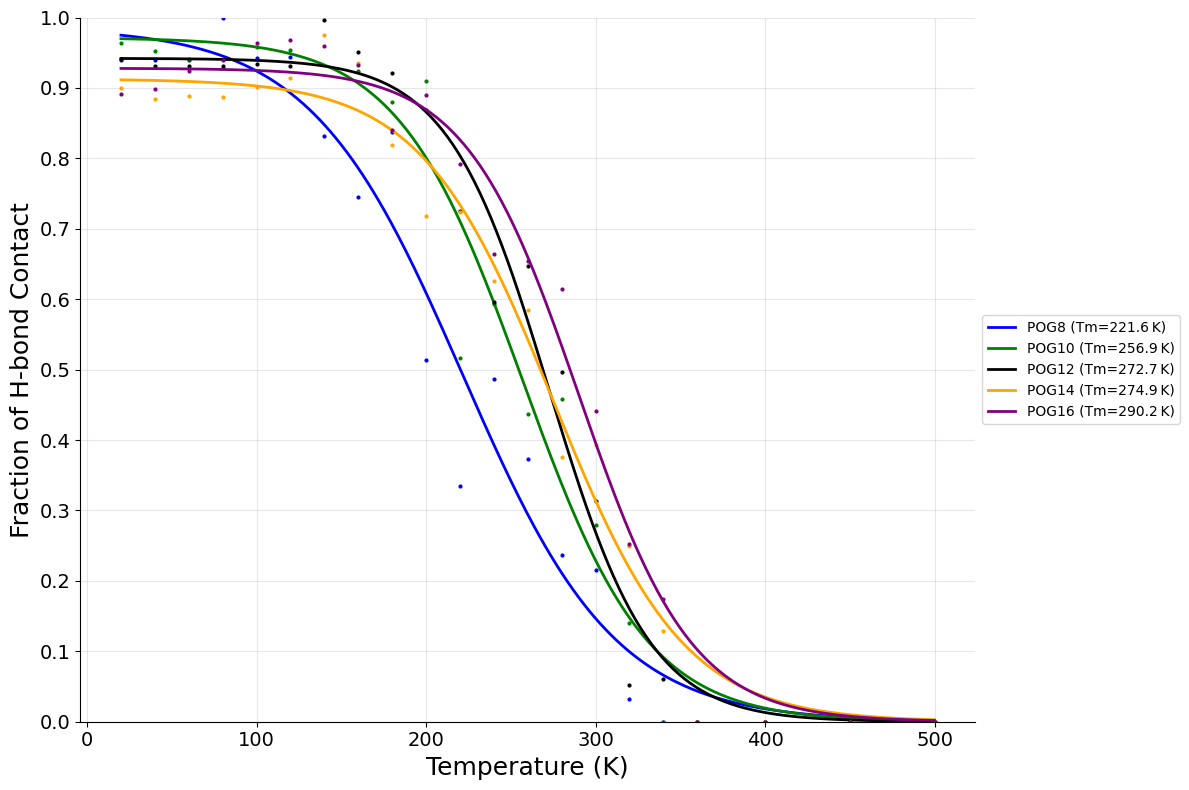

In [27]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

base_dir    = Path("./")
start_frame = 9703
threshold   = 350

systems = {
    #"POG6":  {"max_pairs": 16, "color": "red"},
    "POG8":  {"max_pairs": 22, "color": "blue"},
    "POG10": {"max_pairs": 28, "color": "green"},
    "POG12": {"max_pairs": 34, "color": "black"},
    "POG14": {"max_pairs": 40, "color": "orange"},
    "POG16": {"max_pairs": 46, "color": "purple"},
    "POG18": {"max_pairs": 52, "color": "pink"}
    #"POG20": {"max_pairs": 58, "color": "red"}
}

fig, ax = plt.subplots(figsize=(12,8))

for sys_name, props in systems.items():
    csv_file = base_dir / sys_name / f"{sys_name}_replicas_fraction_summary.csv"
    df = pd.read_csv(csv_file)
    
    T_data = df["Temperature (K)"].values
    F_data = df["Fraction"].values
    
    # pad zeros beyond threshold
    extra_T = np.arange(threshold+50, 501, 50)
    extra_F = np.zeros_like(extra_T, dtype=float)
    T_all   = np.concatenate([T_data, extra_T])
    F_all   = np.concatenate([F_data, extra_F])
    idx     = np.argsort(T_all)
    T_plot, F_plot = T_all[idx], F_all[idx]

    # logistic fit function
    def logistic(T, Tm, k, top):
        return top / (1 + np.exp((T - Tm) / k))

    # choose initial guesses
    if sys_name == "POG12":
        p0 = [np.median(T_data), 5.0, np.max(F_data)]
    else:
        p0 = [np.median(T_data), 5.0, np.max(F_data)]

    popt, _    = curve_fit(logistic, T_data, F_data, p0=p0, maxfev=3000)
    Tm_fit,k_fit,top_fit = popt

    # smooth fit curve
    T_fit = np.linspace(T_plot.min(), T_plot.max(), 300)
    F_fit = logistic(T_fit, Tm_fit, k_fit, top_fit)

    # plot data as small dots
    ax.plot(
        T_plot, F_plot,
        '.', color=props["color"], markersize=4
    )
    # plot fit as a solid curve
    ax.plot(
        T_fit, F_fit,
        '-', color=props["color"], linewidth=2,
        label=f"{sys_name} (Tm={Tm_fit:.1f} K)"
    )

ax.set_xlabel("Temperature (K)", fontsize=18)
ax.set_ylabel("Fraction of H-bond Contact", fontsize=18)
ax.set_ylim(0,1)
ax.set_yticks(np.linspace(0,1,11))
ax.tick_params(axis='both', labelsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()


## TM vs Temp

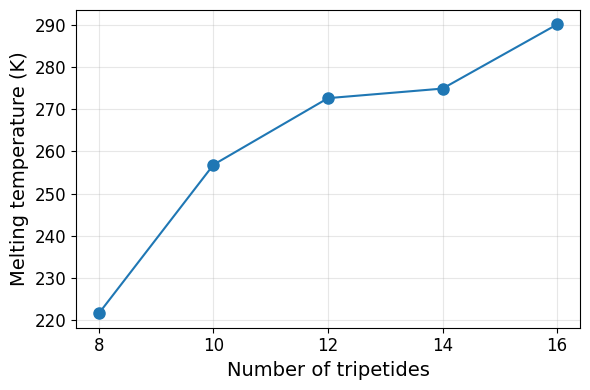

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Base directory containing system folders
base_dir = Path("./")

# Specify exactly which systems to plot (you can comment out or remove names)
systems_to_plot = ["POG8", "POG10", "POG12", "POG14", "POG16", "POG18", "POG20"]

lengths = []
Tm_K    = []

for sys_name in systems_to_plot:
    csv = base_dir / sys_name / f"{sys_name}_replicas_fraction_summary.csv"
    if not csv.exists():
        print(f"⚠️  Missing file for {sys_name}, skipping")
        continue
    df = pd.read_csv(csv)
    
    # grab the fitted Tm in Kelvin
    tm_K = df["Tm_fit"].iloc[0]
    # parse the number of triplets from the name, e.g. "POG12" → 12
    n = int(sys_name.replace("POG", ""))
    
    lengths.append(n)
    Tm_K.append(tm_K)

# sort by length
order = np.argsort(lengths)
lengths = np.array(lengths)[order]
Tm_K    = np.array(Tm_K)[order]

# Plot
plt.figure(figsize=(6,4))
plt.plot(lengths, Tm_K, "o-", lw=1.5, ms=8)
plt.xlabel("Number of tripetides", fontsize=14)
plt.ylabel("Melting temperature (K)", fontsize=14)
plt.xticks(lengths, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
